<a href="https://colab.research.google.com/github/HitanshuGedam/quantum-learning-journey/blob/main/Day6_Bloch_Ball_Visualizing_Mixed_States.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 6: Bloch Ball - Visualizing Mixed States

## From Pure States to Statistical Ensembles

## Learning Objectives

By the end of this notebook, you will understand:

1. The Bloch ball representation of qubit states
2. How mixed states correspond to interior points of the Bloch ball
3. The relationship between Bloch vector length and purity
4. How to visualize different mixed states on the Bloch ball
5. The geometric interpretation of decoherence as movement toward the center or poles
6. How to generate and visualize random mixed states

## Philosophical Motivation

The Bloch sphere is a powerful visualization tool for pure quantum states. However, real quantum systems are never perfectly isolated — they interact with their environment, leading to decoherence and mixed states. The Bloch ball extends this visualization to include mixed states, with the radius representing the degree of coherence. Understanding this geometry is essential for grasping decoherence, noise, and quantum thermodynamics.


## References

- https://qubit.guide/8.4-the-bloch-ball
- QuTiP Documentation: https://qutip.org/

In [1]:
# ============================================================================
# SETUP AND INSTALLATIONS
# ============================================================================

!pip install qutip qutip_qip -q

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print(f"NumPy version: {np.__version__}")
print(f"QuTiP version: {qt.__version__}")
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 10.7 MB/s eta 0:00:00
NumPy version: 2.0.2
QuTiP version: 5.2.3
Setup complete.


## 1. The Bloch Ball: Extending the Bloch Sphere

### Bloch Sphere vs Bloch Ball

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Feature</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Bloch Sphere</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Bloch Ball</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">States Represented</td>
            <td style="padding: 8px;">Pure states only</td>
            <td style="padding: 8px;">All states (pure + mixed)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Geometry</td>
            <td style="padding: 8px;">Sphere surface ($r = 1$)</td>
            <td style="padding: 8px;">Solid ball ($0 \le r \le 1$)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Bloch Vector Length</td>
            <td style="padding: 8px;">$|\vec{r}| = 1$</td>
            <td style="padding: 8px;">$|\vec{r}| \le 1$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Purity (Qubit Range)</td>
            <td style="padding: 8px;">$\text{Tr}(\rho^2) = 1$</td>
            <td style="padding: 8px;">$1/2 \le \text{Tr}(\rho^2) \le 1$</td>
        </tr>
    </tbody>
</table>

*Note: The purity range $1/2 \le \text{Tr}(\rho^2) \le 1$ is specific to qubits (dimension 2). For a general d-dimensional system, purity ranges from $1/d$ to $1$.*

### Bloch Vector Representation

For any qubit state (pure or mixed):

$$ \rho = \frac{1}{2}(I + \vec{r} \cdot \vec{\sigma}) $$

where $\vec{r} = (r_x, r_y, r_z)$ is the Bloch vector with $|\vec{r}| \leq 1$

### Key Relationships

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Quantity</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Formula</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Range</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Bloch vector length</td>
            <td style="padding: 8px;">$r = |\vec{r}|$</td>
            <td style="padding: 8px;">$0 \leq r \leq 1$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Purity</td>
            <td style="padding: 8px;">$\text{Tr}(\rho^2) = \frac{1 + r^2}{2}$</td>
            <td style="padding: 8px;">$1/2 \leq \text{Tr}(\rho^2) \leq 1$ (qubits)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">von Neumann entropy</td>
            <td style="padding: 8px;">$S(\rho) = -\frac{1+r}{2}\log_2\left(\frac{1+r}{2}\right) - \frac{1-r}{2}\log_2\left(\frac{1-r}{2}\right)$</td>
            <td style="padding: 8px;">$0 \leq S(\rho) \leq 1$</td>
        </tr>
    </tbody>
</table>

BLOCH VECTOR LENGTH VS PURITY


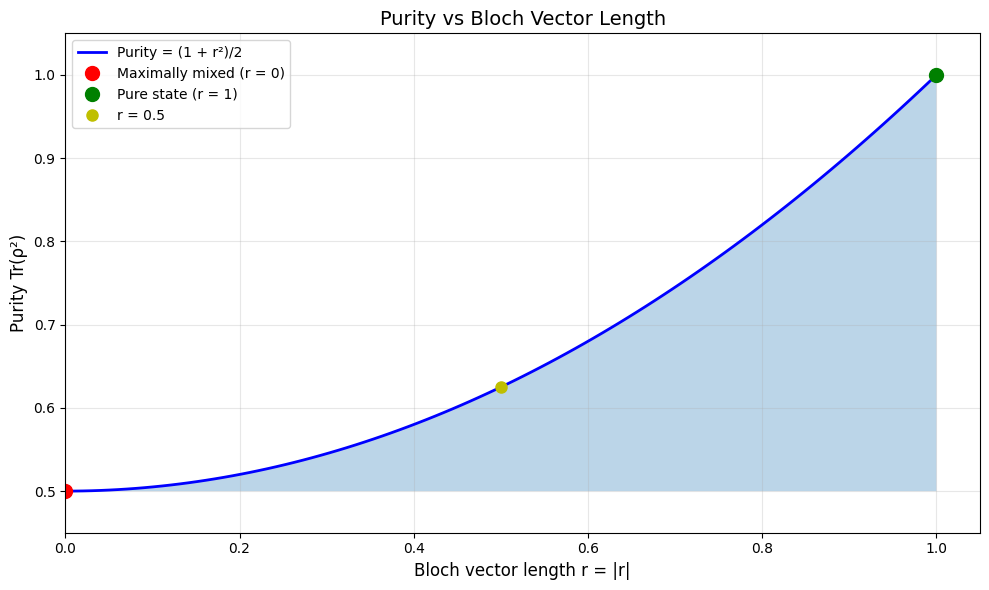


Observations:
- r = 0: Maximally mixed state (purity = 0.5)
- r = 1: Pure state (purity = 1)
- r = 0.5: Purity = (1 + 0.25)/2 = 0.625
- Purity increases quadratically with r


In [2]:
# ============================================================================
# BLOCH VECTOR AND PURITY RELATIONSHIP
# ============================================================================

print("=" * 70)
print("BLOCH VECTOR LENGTH VS PURITY")
print("=" * 70)

# Generate r values from 0 to 1
r_values = np.linspace(0, 1, 100)
purity_values = (1 + r_values**2) / 2

# Plot the relationship
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(r_values, purity_values, 'b-', linewidth=2, label='Purity = (1 + r²)/2')
ax.fill_between(r_values, 0.5, purity_values, alpha=0.3)

# Mark special points
ax.plot(0, 0.5, 'ro', markersize=10, label='Maximally mixed (r = 0)')
ax.plot(1, 1, 'go', markersize=10, label='Pure state (r = 1)')
ax.plot(0.5, (1 + 0.25)/2, 'yo', markersize=8, label='r = 0.5')

ax.set_xlabel('Bloch vector length r = |r|', fontsize=12)
ax.set_ylabel('Purity Tr(ρ²)', fontsize=12)
ax.set_title('Purity vs Bloch Vector Length', fontsize=14)
ax.set_xlim([0, 1.05])
ax.set_ylim([0.45, 1.05])
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- r = 0: Maximally mixed state (purity = 0.5)")
print("- r = 1: Pure state (purity = 1)")
print("- r = 0.5: Purity = (1 + 0.25)/2 = 0.625")
print("- Purity increases quadratically with r")

## 2. Visualizing Mixed States on the Bloch Ball

### Radial Lines: States with Different Purity

States along the same direction but with different Bloch vector lengths:

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Direction</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">$r = 1$ (Pure)</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">$r = 0.5$</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">$r = 0$ (Maximally mixed)</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$+X$ axis</td>
            <td style="padding: 8px;">$|+\rangle$</td>
            <td style="padding: 8px;">$\frac{1}{2}(I + 0.5 X)$</td>
            <td style="padding: 8px;">$I/2$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$+Y$ axis</td>
            <td style="padding: 8px;">$|{+i}\rangle = \frac{1}{\sqrt{2}}(|0\rangle + i|1\rangle)$</td>
            <td style="padding: 8px;">$\frac{1}{2}(I + 0.5 Y)$</td>
            <td style="padding: 8px;">$I/2$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$+Z$ axis</td>
            <td style="padding: 8px;">$|0\rangle$</td>
            <td style="padding: 8px;">$\frac{1}{2}(I + 0.5 Z)$</td>
            <td style="padding: 8px;">$I/2$</td>
        </tr>
    </tbody>
</table>

### The Bloch Ball Visualization

The Bloch ball shows:
- **Surface ($r = 1$):** Pure states (maximal coherence)
- **Interior ($r < 1$):** Mixed states (partial coherence)
- **Center ($r = 0$):** Maximally mixed state (no coherence)

### Interpretation

As a quantum state decoheres, its Bloch vector evolves according to the specific noise channel:
- **Depolarization:** Shrinks toward the center
- **Relaxation (T₁):** Drives toward the north pole $|0\rangle$
- **Dephasing (T₂):** Shrinks $x$ and $y$ components only

BLOCH BALL VISUALIZATION - PRINCIPAL AXES

Drawing principal axes (1D slices)...

Verifying axis directions (pure states at r=1):
  +X axis (|+⟩): Bloch vector = (+1.00, +0.00, +0.00)
  +Y axis (|+i⟩): Bloch vector = (+0.00, +1.00, +0.00)
  +Z axis (|0⟩): Bloch vector = (+0.00, +0.00, +1.00)


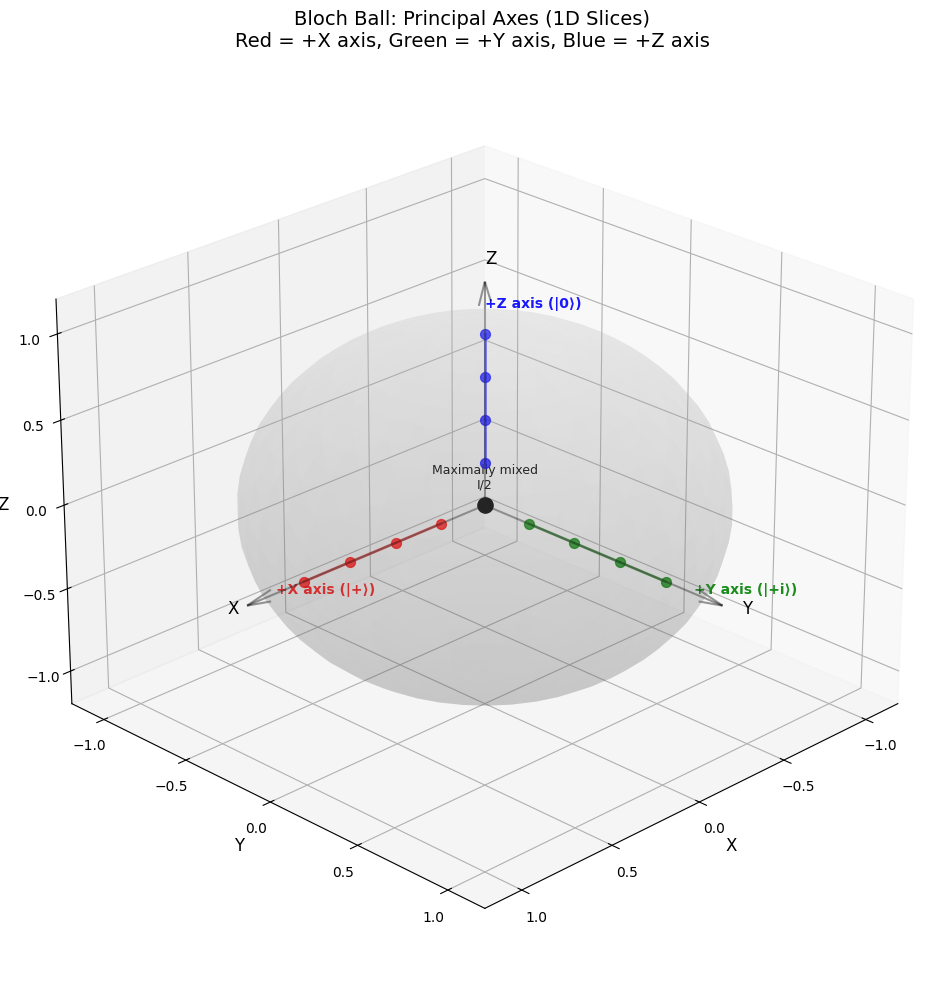


GEOMETRIC INTERPRETATION

┌─────────────────────────────────────────────────────────────────────────────┐
│  BLOCH BALL PRINCIPAL AXES                                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  Red line (X-axis):                                                        │
│    • r = 1: |+⟩ = (|0⟩ + |1⟩)/√2 → Bloch vector (1, 0, 0)                  │
│    • r < 1: Mixed states along X-axis                                      │
│                                                                             │
│  Green line (Y-axis):                                                      │
│    • r = 1: |+i⟩ = (|0⟩ + i|1⟩)/√2 → Bloch vector (0, 1, 0)                │
│    • r < 1: Mixed states along Y-axis                                      │
│    • Note: Uses -Y operator to get +Y direction                            │
│                   

In [8]:
# ============================================================================
# BLOCH BALL VISUALIZATION - PRINCIPAL AXES ONLY
# ============================================================================

print("=" * 70)
print("BLOCH BALL VISUALIZATION - PRINCIPAL AXES")
print("=" * 70)

def bloch_vector(rho):
    """
    Extract Bloch vector (rx, ry, rz) from a density matrix.

    For a qubit density matrix ρ = (I + rx X + ry Y + rz Z)/2:
        rx = Tr(ρX) = 2 Re(ρ₀₁)
        ry = Tr(ρY) = 2 Im(ρ₀₁)
        rz = Tr(ρZ) = ρ₀₀ - ρ₁₁
    """
    rho_mat = rho.full()
    rx = 2 * np.real(rho_mat[0, 1])
    ry = 2 * np.imag(rho_mat[0, 1])
    rz = np.real(rho_mat[0, 0] - rho_mat[1, 1])
    return np.array([rx, ry, rz])

# ----------------------------------------------------------------------------
# CREATE FIGURE
# ----------------------------------------------------------------------------
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# ----------------------------------------------------------------------------
# 1. DRAW BLOCH SPHERE SURFACE (TRANSPARENT BOUNDARY)
# ----------------------------------------------------------------------------
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 30)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightgray', alpha=0.15, edgecolor='none')

# ----------------------------------------------------------------------------
# 2. DRAW COORDINATE AXES
# ----------------------------------------------------------------------------
ax.quiver(0, 0, 0, 1.3, 0, 0, color='black', arrow_length_ratio=0.1, alpha=0.4)
ax.quiver(0, 0, 0, 0, 1.3, 0, color='black', arrow_length_ratio=0.1, alpha=0.4)
ax.quiver(0, 0, 0, 0, 0, 1.3, color='black', arrow_length_ratio=0.1, alpha=0.4)

# Add axis labels
ax.text(1.4, 0, 0, 'X', fontsize=12)
ax.text(0, 1.4, 0, 'Y', fontsize=12)
ax.text(0, 0, 1.4, 'Z', fontsize=12)

# ----------------------------------------------------------------------------
# 3. DRAW PRINCIPAL AXES (1D SLICES OF THE BLOCH BALL)
# ----------------------------------------------------------------------------
# Note: For Y-axis, we use -Y to get +Y direction in Bloch vector
# Because ρ = (I + Y)/2 gives ry = -1, so we use ρ = (I - Y)/2 to get ry = +1

# X-axis: using +X gives rx = +1
X_op = qt.sigmax()
# Y-axis: using -Y gives ry = +1 (since +Y would give ry = -1)
Y_op = -qt.sigmay()
# Z-axis: using +Z gives rz = +1
Z_op = qt.sigmaz()

operators = [X_op, Y_op, Z_op]
colors = ['red', 'green', 'blue']
labels = ['+X axis (|+⟩)', '+Y axis (|+i⟩)', '+Z axis (|0⟩)']
radii = [1.0, 0.75, 0.5, 0.25]

print("\nDrawing principal axes (1D slices)...")

for op, color, label in zip(operators, colors, labels):
    points = []
    for r in radii:
        rho = 0.5 * (qt.qeye(2) + r * op)
        vec = bloch_vector(rho)
        points.append(vec)
        ax.scatter([vec[0]], [vec[1]], [vec[2]], color=color, s=50, alpha=0.8, zorder=5)

    # Connect points along the radial line
    for i in range(len(radii) - 1):
        ax.plot([points[i][0], points[i+1][0]],
                [points[i][1], points[i+1][1]],
                [points[i][2], points[i+1][2]],
                color=color, alpha=0.6, linewidth=2)

    # Label the pure state at r=1
    rho_pure = 0.5 * (qt.qeye(2) + 1.0 * op)
    vec_pure = bloch_vector(rho_pure)
    ax.text(vec_pure[0]*1.15, vec_pure[1]*1.15, vec_pure[2]*1.15, label,
            color=color, fontsize=10, fontweight='bold', alpha=0.9)

# ----------------------------------------------------------------------------
# 4. ADD CENTER POINT (MAXIMALLY MIXED STATE)
# ----------------------------------------------------------------------------
ax.scatter([0], [0], [0], color='black', s=120, marker='o', zorder=10)
ax.text(0, 0, 0.08, 'Maximally mixed\nI/2', fontsize=9, ha='center', va='bottom')

# ----------------------------------------------------------------------------
# 5. VERIFY THE DIRECTIONS
# ----------------------------------------------------------------------------
print("\nVerifying axis directions (pure states at r=1):")
for op, color, label in zip(operators, colors, labels):
    rho_pure = 0.5 * (qt.qeye(2) + 1.0 * op)
    vec = bloch_vector(rho_pure)
    print(f"  {label}: Bloch vector = ({vec[0]:+.2f}, {vec[1]:+.2f}, {vec[2]:+.2f})")

# ----------------------------------------------------------------------------
# 6. SET LABELS AND VIEW
# ----------------------------------------------------------------------------
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
ax.set_title('Bloch Ball: Principal Axes (1D Slices)\n' +
             'Red = +X axis, Green = +Y axis, Blue = +Z axis',
             fontsize=14)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 7. FINAL SUMMARY
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("GEOMETRIC INTERPRETATION")
print("=" * 70)
print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  BLOCH BALL PRINCIPAL AXES                                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  Red line (X-axis):                                                        │
│    • r = 1: |+⟩ = (|0⟩ + |1⟩)/√2 → Bloch vector (1, 0, 0)                  │
│    • r < 1: Mixed states along X-axis                                      │
│                                                                             │
│  Green line (Y-axis):                                                      │
│    • r = 1: |+i⟩ = (|0⟩ + i|1⟩)/√2 → Bloch vector (0, 1, 0)                │
│    • r < 1: Mixed states along Y-axis                                      │
│    • Note: Uses -Y operator to get +Y direction                            │
│                                                                             │
│  Blue line (Z-axis):                                                       │
│    • r = 1: |0⟩ → Bloch vector (0, 0, 1)                                   │
│    • r < 1: Mixed states along Z-axis                                      │
│                                                                             │
│  Black point at center: Maximally mixed state I/2 (r = 0)                  │
│                                                                             │
│  KEY INSIGHT:                                                              │
│  - Distance from center = purity (coherence)                               │
│  - Direction = orientation of the Bloch vector                             │
│  - Points move from surface (r=1) to center (r=0) as purity decreases      │
└─────────────────────────────────────────────────────────────────────────────┘
""")
print("=" * 70)

## 3. Random Mixed States

### Generating Random Mixed States

Random mixed states can be generated using the Ginibre ensemble or by applying random unitaries to diagonal states.

### Distribution of Bloch Vectors (Qubit Case)

For qubits ($d=2$), the Hilbert-Schmidt measure on density matrices corresponds to the **uniform volume measure** on the Bloch ball. This gives the probability density for the Bloch vector length $r$:

$$ P(r) = 3r^2, \quad 0 \leq r \leq 1 $$

This means:
- States are uniformly distributed by volume in $\mathbb{R}^3$ space
- The factor $r^2$ comes from the spherical Jacobian: $dV = r^2 \sin\theta \, dr \, d\theta \, d\phi$
- Normalization: $\int_0^1 3r^2 dr = 1$

*Important Note:* The equivalence between the Hilbert-Schmidt measure and uniform volume measure on the Bloch ball is **specific to qubits ($d=2$)**. For higher-dimensional systems, the Hilbert-Schmidt measure does not correspond to uniform volume in the parameter space.

### Other Measures

Other measures exist for generating random mixed states:
- **Bures measure:** Different distribution, often used in quantum metrology
- **Ginibre ensemble:** Generates random density matrices with specific properties
- **Random unitaries:** Apply random unitaries to a fixed diagonal state

The choice of measure depends on the physical scenario.

### Visualizing Random Mixed States

Below we generate random mixed states and plot their Bloch vectors inside the Bloch ball.

RANDOM MIXED STATES (HILBERT-SCHMIDT MEASURE)

Generated 800 random mixed states (Hilbert-Schmidt measure)
  → Uniform volume distribution over the Bloch ball
  → P(r) = 3r², 0 ≤ r ≤ 1


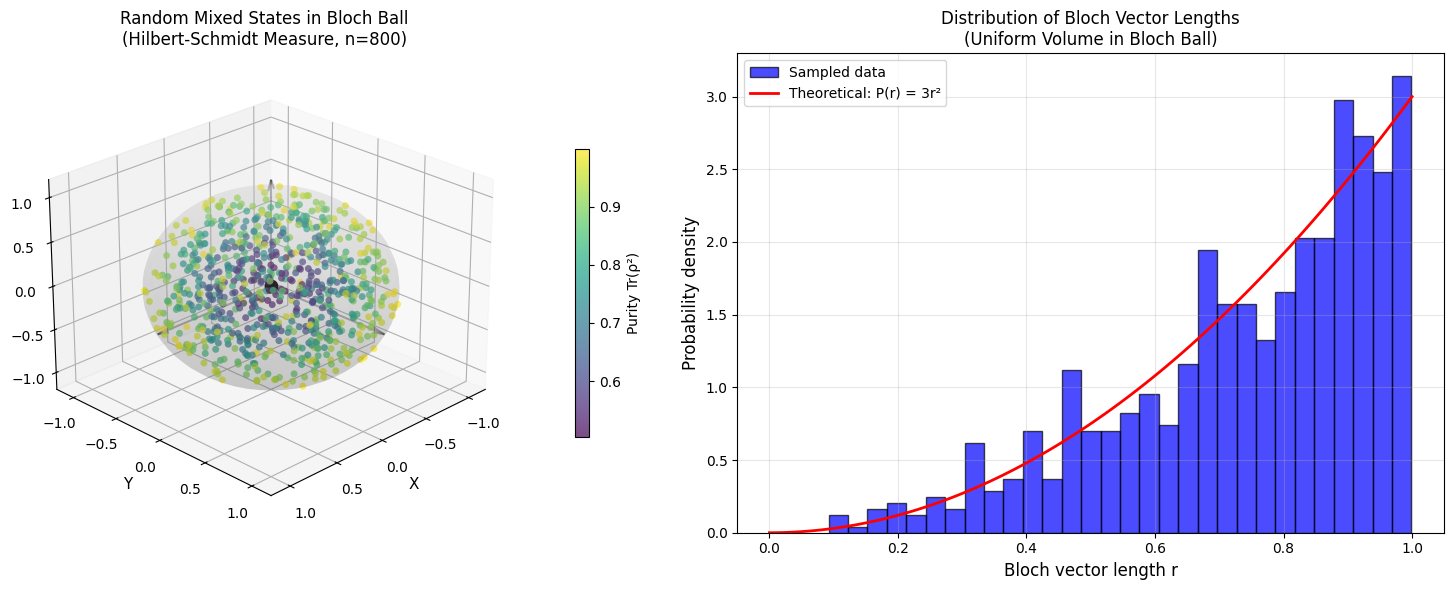


STATISTICS

Bloch vector length r:
  Mean:     0.7454
  Median:   0.7986
  Std dev:  0.2035
  Min:      0.0920
  Max:      0.9991

Purity Tr(ρ²):
  Mean:     0.7985
  Median:   0.8189
  Std dev:  0.1354

Theoretical mean r (uniform volume): 0.7500
  → Sampled mean matches theory: True

Fraction of states with:
  r > 0.9 (near-pure):           27.75%
  0.5 < r < 0.9 (partially mixed): 57.38%
  r < 0.5 (highly mixed):        14.88%
  r < 0.1 (near-maximally mixed): 0.25%

VERIFICATION: UNIFORM VOLUME DISTRIBUTION


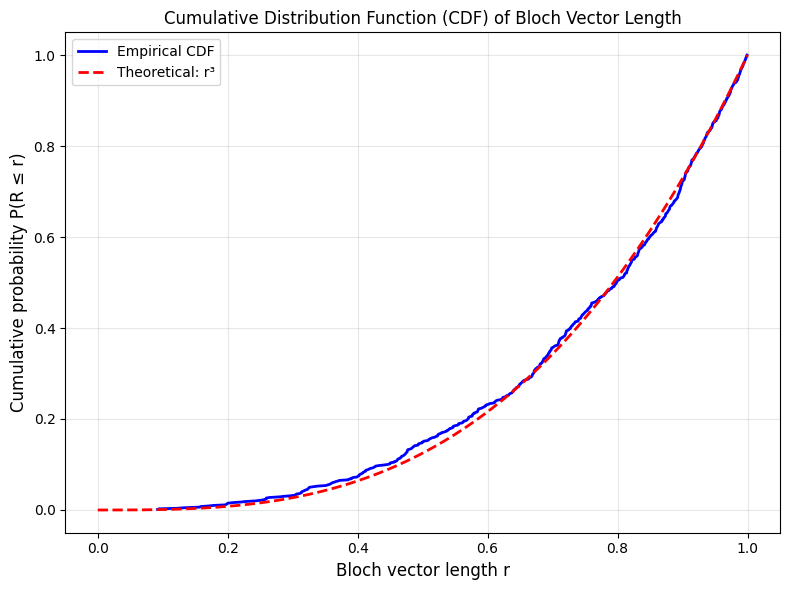


Observations:
- The empirical CDF closely follows r³, confirming uniform volume distribution
- Random states are uniformly distributed throughout the Bloch ball
- The density of points is constant per unit volume
- More points have larger r because volume increases with r³


In [9]:
# ============================================================================
# RANDOM MIXED STATES VISUALIZATION
# ============================================================================

print("=" * 70)
print("RANDOM MIXED STATES (HILBERT-SCHMIDT MEASURE)")
print("=" * 70)

def bloch_vector(rho):
    """Extract Bloch vector from density matrix."""
    rho_mat = rho.full()
    rx = 2 * np.real(rho_mat[0, 1])
    ry = 2 * np.imag(rho_mat[0, 1])
    rz = np.real(rho_mat[0, 0] - rho_mat[1, 1])
    return np.array([float(rx), float(ry), float(rz)])

def random_mixed_state_hs():
    """
    Generate a random mixed state using Hilbert-Schmidt measure.
    For qubits, this corresponds to uniform distribution over the Bloch ball volume.
    """
    # Generate random Bloch vector uniformly distributed in the ball by volume
    # Method: r = u^(1/3) gives uniform volume distribution (since P(r) = 3r²)
    while True:
        # Random direction (uniform on sphere)
        theta = np.random.uniform(0, 2 * np.pi)
        phi = np.arccos(2 * np.random.uniform() - 1)

        # Random radius with uniform volume distribution
        r = np.random.uniform() ** (1/3)

        # Cartesian coordinates
        x = r * np.sin(phi) * np.cos(theta)
        y = r * np.sin(phi) * np.sin(theta)
        z = r * np.cos(phi)

        # Ensure we're inside the sphere (should always be true with this method)
        if x**2 + y**2 + z**2 <= 1:
            break

    # Create density matrix from Bloch vector
    rho = 0.5 * (qt.qeye(2) + x * qt.sigmax() + y * qt.sigmay() + z * qt.sigmaz())
    return rho, (x, y, z, r)

# Generate random states
num_states = 800
random_states = [random_mixed_state_hs() for _ in range(num_states)]

# Extract Bloch vectors and purities
bloch_vectors = np.array([vec for _, vec in random_states])
x_vals = bloch_vectors[:, 0]
y_vals = bloch_vectors[:, 1]
z_vals = bloch_vectors[:, 2]
r_vals = bloch_vectors[:, 3]
purity_vals = (1 + r_vals**2) / 2

print(f"\nGenerated {num_states} random mixed states (Hilbert-Schmidt measure)")
print(f"  → Uniform volume distribution over the Bloch ball")
print(f"  → P(r) = 3r², 0 ≤ r ≤ 1")

# Create figure with two subplots
fig = plt.figure(figsize=(15, 6))

# ============================================================================
# LEFT: 3D Bloch ball with random points
# ============================================================================
ax1 = fig.add_subplot(121, projection='3d')

# Draw Bloch sphere surface
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:30j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)
ax1.plot_surface(x_sphere, y_sphere, z_sphere, color='lightgray', alpha=0.15, edgecolor='none')

# Draw coordinate axes
ax1.quiver(0, 0, 0, 1.2, 0, 0, color='black', arrow_length_ratio=0.1, alpha=0.3)
ax1.quiver(0, 0, 0, 0, 1.2, 0, color='black', arrow_length_ratio=0.1, alpha=0.3)
ax1.quiver(0, 0, 0, 0, 0, 1.2, color='black', arrow_length_ratio=0.1, alpha=0.3)

# Plot random points colored by purity
scatter = ax1.scatter(x_vals, y_vals, z_vals, c=purity_vals, cmap='viridis',
                      s=25, alpha=0.7, edgecolors='none')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax1, shrink=0.6, pad=0.1)
cbar.set_label('Purity Tr(ρ²)', fontsize=10)

# Mark center
ax1.scatter([0], [0], [0], color='black', s=80, marker='o', zorder=10)

ax1.set_xlabel('X', fontsize=11)
ax1.set_ylabel('Y', fontsize=11)
ax1.set_zlabel('Z', fontsize=11)
ax1.set_title(f'Random Mixed States in Bloch Ball\n(Hilbert-Schmidt Measure, n={num_states})', fontsize=12)
ax1.view_init(elev=25, azim=45)
ax1.set_xlim([-1.2, 1.2])
ax1.set_ylim([-1.2, 1.2])
ax1.set_zlim([-1.2, 1.2])

# ============================================================================
# RIGHT: Histogram of Bloch vector lengths
# ============================================================================
ax2 = fig.add_subplot(122)

# Histogram of r values
counts, bins, patches = ax2.hist(r_vals, bins=30, density=True, alpha=0.7,
                                  color='blue', edgecolor='black', label='Sampled data')

# Theoretical distribution P(r) = 3r²
r_theory = np.linspace(0, 1, 100)
p_theory = 3 * r_theory**2
ax2.plot(r_theory, p_theory, 'r-', linewidth=2, label='Theoretical: P(r) = 3r²')

ax2.set_xlabel('Bloch vector length r', fontsize=12)
ax2.set_ylabel('Probability density', fontsize=12)
ax2.set_title('Distribution of Bloch Vector Lengths\n(Uniform Volume in Bloch Ball)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# STATISTICS
# ============================================================================
print("\n" + "=" * 70)
print("STATISTICS")
print("=" * 70)

print(f"\nBloch vector length r:")
print(f"  Mean:     {np.mean(r_vals):.4f}")
print(f"  Median:   {np.median(r_vals):.4f}")
print(f"  Std dev:  {np.std(r_vals):.4f}")
print(f"  Min:      {np.min(r_vals):.4f}")
print(f"  Max:      {np.max(r_vals):.4f}")

print(f"\nPurity Tr(ρ²):")
print(f"  Mean:     {np.mean(purity_vals):.4f}")
print(f"  Median:   {np.median(purity_vals):.4f}")
print(f"  Std dev:  {np.std(purity_vals):.4f}")

# Compare with theoretical expectation for uniform volume
# E[r] = ∫₀¹ r * 3r² dr = 3∫₀¹ r³ dr = 3/4 = 0.75
theoretical_mean_r = 3/4
print(f"\nTheoretical mean r (uniform volume): {theoretical_mean_r:.4f}")
print(f"  → Sampled mean matches theory: {np.abs(np.mean(r_vals) - theoretical_mean_r) < 0.02}")

# Fraction of states in different regions
print(f"\nFraction of states with:")
print(f"  r > 0.9 (near-pure):           {np.sum(r_vals > 0.9) / num_states:.2%}")
print(f"  0.5 < r < 0.9 (partially mixed): {np.sum((r_vals > 0.5) & (r_vals < 0.9)) / num_states:.2%}")
print(f"  r < 0.5 (highly mixed):        {np.sum(r_vals < 0.5) / num_states:.2%}")
print(f"  r < 0.1 (near-maximally mixed): {np.sum(r_vals < 0.1) / num_states:.2%}")

# ============================================================================
# VERIFICATION OF UNIFORM VOLUME DISTRIBUTION
# ============================================================================
print("\n" + "=" * 70)
print("VERIFICATION: UNIFORM VOLUME DISTRIBUTION")
print("=" * 70)

# The volume of a sphere of radius r is V(r) = (4/3)πr³
# For uniform volume, the cumulative distribution should be P(R ≤ r) = r³
# Let's check this empirically

# Sort r values
r_sorted = np.sort(r_vals)
# Empirical CDF
empirical_cdf = np.arange(1, num_states + 1) / num_states
# Theoretical CDF: r³
r_cdf = np.linspace(0, 1, 100)
theoretical_cdf = r_cdf**3

fig3, ax3 = plt.subplots(figsize=(8, 6))
ax3.plot(r_sorted, empirical_cdf, 'b-', linewidth=2, label='Empirical CDF')
ax3.plot(r_cdf, theoretical_cdf, 'r--', linewidth=2, label='Theoretical: r³')
ax3.set_xlabel('Bloch vector length r', fontsize=12)
ax3.set_ylabel('Cumulative probability P(R ≤ r)', fontsize=12)
ax3.set_title('Cumulative Distribution Function (CDF) of Bloch Vector Length', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- The empirical CDF closely follows r³, confirming uniform volume distribution")
print("- Random states are uniformly distributed throughout the Bloch ball")
print("- The density of points is constant per unit volume")
print("- More points have larger r because volume increases with r³")

## 4. Decoherence as Movement in the Bloch Ball

### Geometric Picture of Decoherence

Different decoherence channels affect the Bloch vector differently:

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Channel</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Effect on Bloch Vector</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Steady State</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Dephasing ($T_2$)</td>
            <td style="padding: 8px;">Shrinks $x$ and $y$ components only (exponential decay)</td>
            <td style="padding: 8px;">Z-axis (any point on it, preserving $r_z(0)$)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Relaxation ($T_1$)</td>
            <td style="padding: 8px;">Shrinks $x$, $y$; drives $z \to +1$ exponentially\n
            <td style="padding: 8px;">North pole $|0\rangle$ ($z = +1$) at zero temperature</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Depolarization (single timescale $T$)</td>
            <td style="padding: 8px;">Shrinks all components equally: $\vec{r}(t) = e^{-t/T} \vec{r}(0)$</td>
            <td style="padding: 8px;">Center $I/2$ ($\vec{r} = 0$)</td>
        </tr>
    </tbody>
</table>

*Note: At finite temperature, the relaxation steady state is $r_z \to \tanh(\hbar\omega/2k_BT)$, not $+1$. Real quantum hardware operates at very low but nonzero temperatures, so $r_z(\infty)$ is close to but not exactly $+1$.*

### General Decoherence Equations

For a qubit under combined relaxation and dephasing (at zero temperature):

$$ r_x(t) = r_x(0) e^{-t/T_2}, \quad r_y(t) = r_y(0) e^{-t/T_2} $$

$$ r_z(t) = r_z(0) e^{-t/T_1} + (1 - e^{-t/T_1}) $$

The $+1$ in the $r_z$ equation comes from the thermal steady state at zero temperature (the north pole $|0\rangle$).

### Fundamental Constraint

From the Lindblad master equation, the relaxation and dephasing times satisfy:

$$ T_2 \leq 2T_1 $$

- **Upper bound $T_2 = 2T_1$:** Occurs when there is no pure dephasing contribution beyond what relaxation itself causes
- **$T_2 < 2T_1$:** Additional pure dephasing processes are present
- **Physical meaning:** You cannot dephase faster than relaxation allows

### Special Cases

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Channel</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">$T_1$</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">$T_2$</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Behavior</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Pure dephasing</td>
            <td style="padding: 8px;">$\infty$ (no decay)</td>
            <td style="padding: 8px;">Finite</td>
            <td style="padding: 8px;">Only $x$ and $y$ decay; $z$ constant</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Pure relaxation</td>
            <td style="padding: 8px;">Finite</td>
            <td style="padding: 8px;">$2T_1$ (upper bound)</td>
            <td style="padding: 8px;">$z$ decays to $+1$; $x$, $y$ decay at rate $1/T_2 = 1/(2T_1)$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Depolarization</td>
            <td style="padding: 8px;">Single timescale $T$</td>
            <td style="padding: 8px;">Single timescale $T$</td>
            <td style="padding: 8px;">All components decay equally to 0: $\vec{r}(t) = e^{-t/T} \vec{r}(0)$</td>
        </tr>
    </tbody>
</table>

*Note: The pure relaxation row shows the limiting case $T_2 = 2T_1$. In real systems, additional pure dephasing reduces $T_2$ below this bound.*

### Visualization

Below we visualize the trajectory of a state undergoing **depolarization** (movement directly toward the center).

DEPOLARIZATION TRAJECTORY


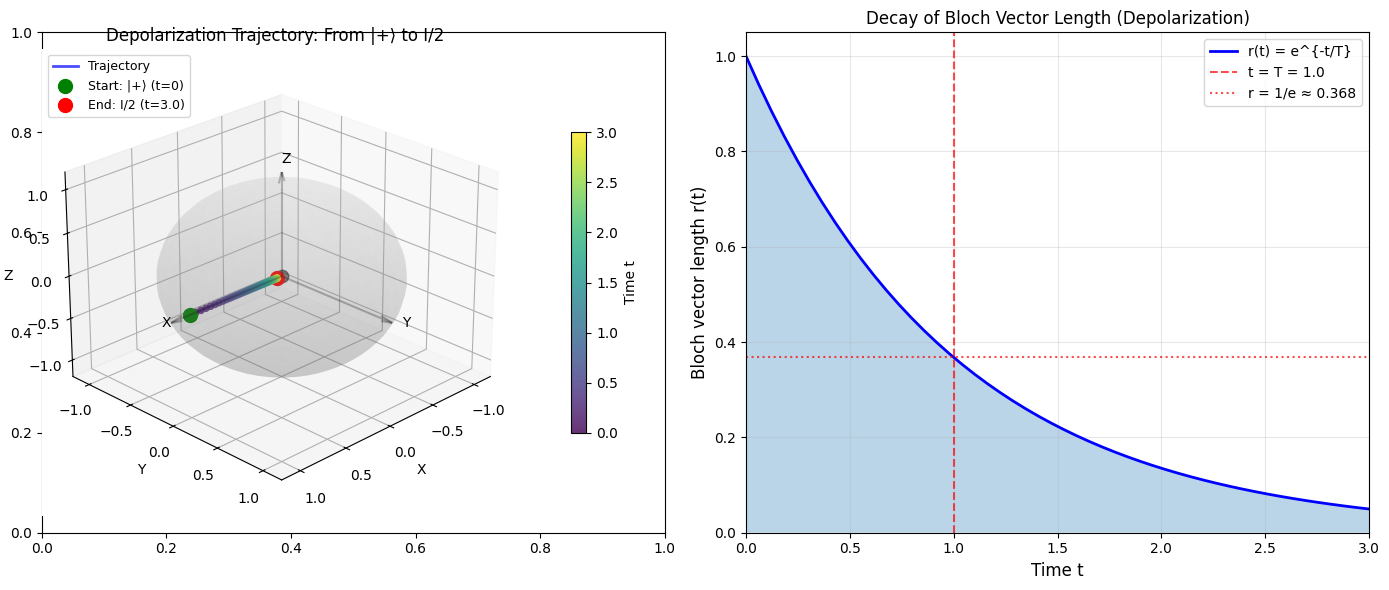


DEPOLARIZATION CHANNEL SUMMARY

┌─────────────────────────────────────────────────────────────────────────────┐
│  DEPOLARIZATION CHANNEL                                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  • Effect: All Bloch vector components decay equally                        │
│  • Equation: r(t) = r(0) e^{-t/T}                                           │
│  • Steady state: Maximally mixed state I/2 (r = 0)                          │
│                                                                             │
│  OBSERVATIONS FROM PLOT:                                                    │
│  ───────────────────────                                                    │
│  • Initial state: |+⟩ (r = 1, on +X axis)                                   │
│  • Trajectory: Straight line from surface to center                         │
│  • At

In [12]:
# ============================================================================
# DEPOLARIZATION TRAJECTORY (Movement Toward Center)
# ============================================================================

print("=" * 70)
print("DEPOLARIZATION TRAJECTORY")
print("=" * 70)

def bloch_vector(rho):
    """Extract Bloch vector from density matrix."""
    rho_mat = rho.full()
    rx = 2 * np.real(rho_mat[0, 1])
    ry = 2 * np.imag(rho_mat[0, 1])
    rz = np.real(rho_mat[0, 0] - rho_mat[1, 1])
    return np.array([float(rx), float(ry), float(rz)])

# Initial pure state |+⟩ (on equator along +X)
initial_x, initial_y, initial_z = 1.0, 0.0, 0.0

# Depolarization parameter (all components decay equally)
T_depol = 1.0  # Characteristic time constant
times = np.linspace(0, 3, 50)

# Calculate trajectory for depolarization: r(t) = r(0) * e^(-t/T)
trajectory = []
for t in times:
    decay = np.exp(-t / T_depol)
    x = initial_x * decay
    y = initial_y * decay
    z = initial_z * decay
    r = np.sqrt(x**2 + y**2 + z**2)
    trajectory.append((x, y, z, r))

x_traj = [p[0] for p in trajectory]
y_traj = [p[1] for p in trajectory]
z_traj = [p[2] for p in trajectory]
r_traj = [p[3] for p in trajectory]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ============================================================================
# LEFT: 3D Trajectory in Bloch Ball
# ============================================================================
ax1 = fig.add_subplot(121, projection='3d')

# Draw Bloch sphere surface
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:30j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)
ax1.plot_surface(x_sphere, y_sphere, z_sphere, color='lightgray', alpha=0.15, edgecolor='none')

# Draw coordinate axes
ax1.quiver(0, 0, 0, 1.2, 0, 0, color='black', arrow_length_ratio=0.1, alpha=0.3)
ax1.quiver(0, 0, 0, 0, 1.2, 0, color='black', arrow_length_ratio=0.1, alpha=0.3)
ax1.quiver(0, 0, 0, 0, 0, 1.2, color='black', arrow_length_ratio=0.1, alpha=0.3)

# Add axis labels
ax1.text(1.3, 0, 0, 'X', fontsize=10)
ax1.text(0, 1.3, 0, 'Y', fontsize=10)
ax1.text(0, 0, 1.3, 'Z', fontsize=10)

# Plot trajectory as a line
ax1.plot(x_traj, y_traj, z_traj, 'b-', alpha=0.7, linewidth=2, label='Trajectory')

# Plot points along trajectory with color map
scatter = ax1.scatter(x_traj, y_traj, z_traj, c=times, cmap='viridis',
                       s=30, alpha=0.8, edgecolors='none')

# Mark start and end points
ax1.scatter([x_traj[0]], [y_traj[0]], [z_traj[0]], color='green', s=100,
            marker='o', zorder=10, label='Start: |+⟩ (t=0)')
ax1.scatter([x_traj[-1]], [y_traj[-1]], [z_traj[-1]], color='red', s=100,
            marker='o', zorder=10, label=f'End: I/2 (t={times[-1]:.1f})')

# Add center point
ax1.scatter([0], [0], [0], color='black', s=80, marker='o', zorder=5, alpha=0.5)

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Depolarization Trajectory: From |+⟩ to I/2', fontsize=12)
ax1.legend(loc='upper left', fontsize=9)
ax1.view_init(elev=25, azim=45)
ax1.set_xlim([-1.2, 1.2])
ax1.set_ylim([-1.2, 1.2])
ax1.set_zlim([-1.2, 1.2])

cbar = plt.colorbar(scatter, ax=ax1, shrink=0.6, pad=0.1)
cbar.set_label('Time t', fontsize=10)

# ============================================================================
# RIGHT: Bloch vector length vs time
# ============================================================================
ax2 = axes[1]
ax2.plot(times, r_traj, 'b-', linewidth=2, label='r(t) = e^{-t/T}')
ax2.fill_between(times, 0, r_traj, alpha=0.3)

# Mark characteristic time T
ax2.axvline(x=T_depol, color='red', linestyle='--', alpha=0.7, label=f't = T = {T_depol}')
ax2.axhline(y=np.exp(-1), color='red', linestyle=':', alpha=0.7, label=f'r = 1/e ≈ 0.368')

ax2.set_xlabel('Time t', fontsize=12)
ax2.set_ylabel('Bloch vector length r(t)', fontsize=12)
ax2.set_title('Decay of Bloch Vector Length (Depolarization)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, times[-1]])
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# ============================================================================
# PRINT SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("DEPOLARIZATION CHANNEL SUMMARY")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  DEPOLARIZATION CHANNEL                                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  • Effect: All Bloch vector components decay equally                        │
│  • Equation: r(t) = r(0) e^{-t/T}                                           │
│  • Steady state: Maximally mixed state I/2 (r = 0)                          │
│                                                                             │
│  OBSERVATIONS FROM PLOT:                                                    │
│  ───────────────────────                                                    │
│  • Initial state: |+⟩ (r = 1, on +X axis)                                   │
│  • Trajectory: Straight line from surface to center                         │
│  • At t = T: r = 1/e ≈ 0.368 (characteristic decay time)                    │
│  • Final state: Maximally mixed at center (r → 0)                           │
│                                                                             │
│  NOTE ON OTHER DECOHERENCE CHANNELS:                                        │
│  ───────────────────────────────────────                                    │
│  • Pure dephasing (T₂): Shrinks only x and y; z constant                    │
│  • Pure relaxation (T₁): Drives toward north pole |0⟩ (z → +1)              │
│  • Combined: Governed by T₁ and T₂ with T₂ ≤ 2T₁                            │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("=" * 70)

## 5. Purity and Entropy on the Bloch Ball

### Visualizing Purity and Entropy

Purity and von Neumann entropy are functions of the Bloch vector length $r$ only — they do not depend on the direction of the Bloch vector. This is because both quantities are invariant under unitary transformations (rotations of the Bloch ball).

### Definitions

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Quantity</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Formula</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Range (Qubit)</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Bloch vector length</td>
            <td style="padding: 8px;">$r = |\vec{r}| = \sqrt{r_x^2 + r_y^2 + r_z^2}$</td>
            <td style="padding: 8px;">$0 \leq r \leq 1$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Purity</td>
            <td style="padding: 8px;">$\text{Tr}(\rho^2) = \frac{1 + r^2}{2}$</td>
            <td style="padding: 8px;">$1/2 \leq \text{Tr}(\rho^2) \leq 1$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">von Neumann entropy</td>
            <td style="padding: 8px;">$S(\rho) = -\frac{1+r}{2}\log_2\left(\frac{1+r}{2}\right) - \frac{1-r}{2}\log_2\left(\frac{1-r}{2}\right)$</td>
            <td style="padding: 8px;">$0 \leq S(\rho) \leq 1$</td>
        </tr>
    </tbody>
</table>

*Note: The von Neumann entropy formula assumes $\log_2$ (information entropy). For natural units, use $\ln$.*

### Key Values

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">$r$</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">State Type</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Purity $\text{Tr}(\rho^2)$</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Entropy $S(\rho)$</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$r = 1$</td>
            <td style="padding: 8px;">Pure state</td>
            <td style="padding: 8px;">$1$</td>
            <td style="padding: 8px;">$0$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$r = 0.5$</td>
            <td style="padding: 8px;">Partially mixed</td>
            <td style="padding: 8px;">$0.625$</td>
            <td style="padding: 8px;">$\approx 0.811$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$r = 0$</td>
            <td style="padding: 8px;">Maximally mixed</td>
            <td style="padding: 8px;">$0.5$</td>
            <td style="padding: 8px;">$1$</td>
        </tr>
    </tbody>
</table>

### Relationship Between Purity and Entropy

Purity and entropy are **inversely related** measures of mixedness:

- **Higher purity** → Lower entropy (more ordered, more quantum)
- **Lower purity** → Higher entropy (more disordered, more classical)
- **Pure state:** Maximum purity (1), zero entropy
- **Maximally mixed:** Minimum purity (1/2), maximum entropy (1)

### Visualization

Below we plot:
1. **Purity vs Bloch vector length** — quadratic relationship
2. **Entropy vs Bloch vector length** — concave decreasing function
3. **Purity vs Entropy** — showing the inverse relationship

PURITY AND ENTROPY ON THE BLOCH BALL


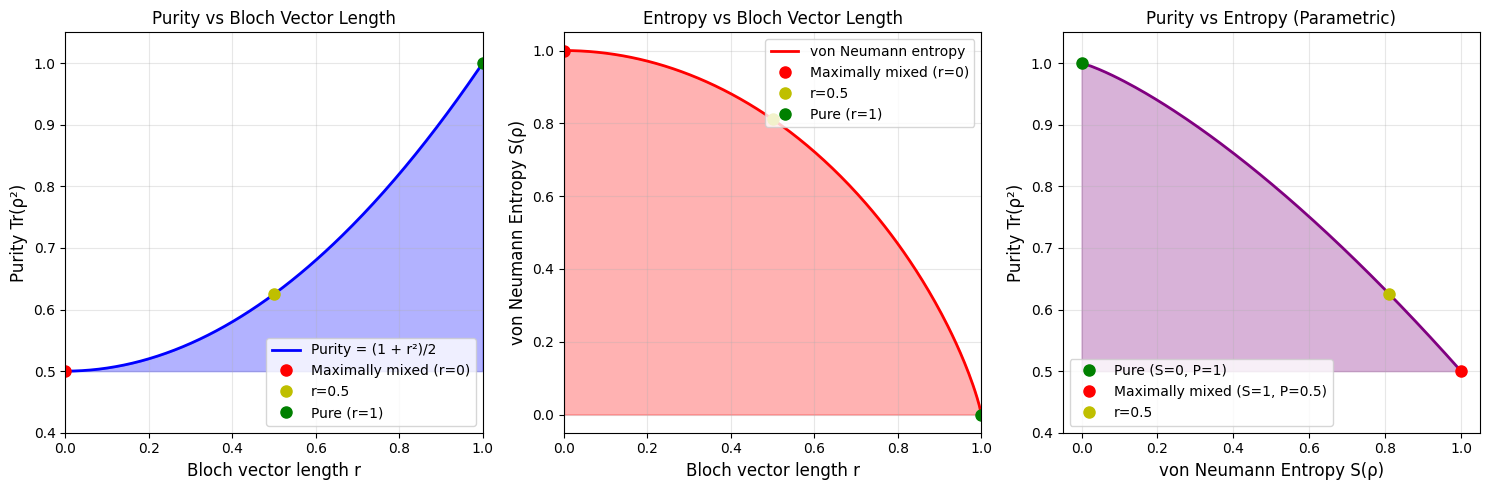


KEY VALUES

r          State Type           Purity       Entropy     
-------------------------------------------------------
1.00       Pure                 1.0000       0.0000      
0.90       Partially mixed      0.9050       0.2864      
0.80       Partially mixed      0.8200       0.4690      
0.70       Partially mixed      0.7450       0.6098      
0.60       Partially mixed      0.6800       0.7219      
0.50       Partially mixed      0.6250       0.8113      
0.40       Partially mixed      0.5800       0.8813      
0.30       Partially mixed      0.5450       0.9341      
0.20       Partially mixed      0.5200       0.9710      
0.10       Partially mixed      0.5050       0.9928      
0.00       Maximally mixed      0.5000       1.0000      

KEY INSIGHTS

┌─────────────────────────────────────────────────────────────────────────────┐
│  RELATIONSHIP BETWEEN PURITY AND ENTROPY                                    │
├───────────────────────────────────────────────────────────

In [13]:
# ============================================================================
# PURITY AND ENTROPY ON THE BLOCH BALL
# ============================================================================

print("=" * 70)
print("PURITY AND ENTROPY ON THE BLOCH BALL")
print("=" * 70)

def purity_from_r(r):
    """Calculate purity from Bloch vector length."""
    return (1 + r**2) / 2

def entropy_from_r(r):
    """Calculate von Neumann entropy from Bloch vector length."""
    if r >= 1 - 1e-12:
        return 0.0
    if r <= 1e-12:
        return 1.0
    p_plus = (1 + r) / 2
    p_minus = (1 - r) / 2
    return -p_plus * np.log2(p_plus) - p_minus * np.log2(p_minus)

# Generate r values from 0 to 1
r_vals = np.linspace(0, 1, 200)
purity_vals = purity_from_r(r_vals)
entropy_vals = [entropy_from_r(r) for r in r_vals]

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ============================================================================
# PLOT 1: Purity vs r
# ============================================================================
ax1 = axes[0]
ax1.plot(r_vals, purity_vals, 'b-', linewidth=2, label='Purity = (1 + r²)/2')
ax1.fill_between(r_vals, 0.5, purity_vals, alpha=0.3, color='blue')

# Mark special points
ax1.plot(0, 0.5, 'ro', markersize=8, label='Maximally mixed (r=0)')
ax1.plot(0.5, purity_from_r(0.5), 'yo', markersize=8, label='r=0.5')
ax1.plot(1, 1, 'go', markersize=8, label='Pure (r=1)')

ax1.set_xlabel('Bloch vector length r', fontsize=12)
ax1.set_ylabel('Purity Tr(ρ²)', fontsize=12)
ax1.set_title('Purity vs Bloch Vector Length', fontsize=12)
ax1.set_xlim([0, 1])
ax1.set_ylim([0.4, 1.05])
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')

# ============================================================================
# PLOT 2: Entropy vs r
# ============================================================================
ax2 = axes[1]
ax2.plot(r_vals, entropy_vals, 'r-', linewidth=2, label='von Neumann entropy')
ax2.fill_between(r_vals, 0, entropy_vals, alpha=0.3, color='red')

# Mark special points
ax2.plot(0, 1, 'ro', markersize=8, label='Maximally mixed (r=0)')
ax2.plot(0.5, entropy_from_r(0.5), 'yo', markersize=8, label='r=0.5')
ax2.plot(1, 0, 'go', markersize=8, label='Pure (r=1)')

ax2.set_xlabel('Bloch vector length r', fontsize=12)
ax2.set_ylabel('von Neumann Entropy S(ρ)', fontsize=12)
ax2.set_title('Entropy vs Bloch Vector Length', fontsize=12)
ax2.set_xlim([0, 1])
ax2.set_ylim([-0.05, 1.05])
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

# ============================================================================
# PLOT 3: Purity vs Entropy (parametric plot)
# ============================================================================
ax3 = axes[2]
ax3.plot(entropy_vals, purity_vals, 'purple', linewidth=2)
ax3.fill_between(entropy_vals, 0.5, purity_vals, alpha=0.3, color='purple')

# Mark special points
ax3.plot(0, 1, 'go', markersize=8, label='Pure (S=0, P=1)')
ax3.plot(1, 0.5, 'ro', markersize=8, label='Maximally mixed (S=1, P=0.5)')
ax3.plot(entropy_from_r(0.5), purity_from_r(0.5), 'yo', markersize=8, label='r=0.5')

ax3.set_xlabel('von Neumann Entropy S(ρ)', fontsize=12)
ax3.set_ylabel('Purity Tr(ρ²)', fontsize=12)
ax3.set_title('Purity vs Entropy (Parametric)', fontsize=12)
ax3.set_xlim([-0.05, 1.05])
ax3.set_ylim([0.4, 1.05])
ax3.grid(True, alpha=0.3)
ax3.legend(loc='lower left')

plt.tight_layout()
plt.show()

# ============================================================================
# PRINT DETAILED VALUES
# ============================================================================
print("\n" + "=" * 70)
print("KEY VALUES")
print("=" * 70)

test_r = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0]
print(f"\n{'r':<10} {'State Type':<20} {'Purity':<12} {'Entropy':<12}")
print("-" * 55)

for r in test_r:
    if r == 1.0:
        state_type = "Pure"
    elif r == 0.0:
        state_type = "Maximally mixed"
    else:
        state_type = "Partially mixed"

    purity = purity_from_r(r)
    entropy = entropy_from_r(r)
    print(f"{r:<10.2f} {state_type:<20} {purity:<12.4f} {entropy:<12.4f}")

# ============================================================================
# ADDITIONAL INSIGHTS
# ============================================================================
print("\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  RELATIONSHIP BETWEEN PURITY AND ENTROPY                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  1. Both purity and entropy depend ONLY on r (Bloch vector length)         │
│     → They are invariant under unitary transformations                     │
│                                                                             │
│  2. Purity decreases monotonically from 1 to 0.5 as r goes from 1 to 0     │
│     → Purity = (1 + r²)/2                                                  │
│                                                                             │
│  3. Entropy increases monotonically from 0 to 1 as r goes from 1 to 0      │
│     → S = -[(1+r)/2] log₂[(1+r)/2] - [(1-r)/2] log₂[(1-r)/2]               │
│                                                                             │
│  4. The relationship is one-to-one: purity uniquely determines entropy     │
│     → For qubits, purity and entropy contain the same information          │
│                                                                             │
│  5. Physical interpretation:                                               │
│     • r = 1: Maximum knowledge (pure state, zero entropy)                  │
│     • r = 0: Minimum knowledge (maximally mixed, entropy = 1)              │
│     • 0 < r < 1: Partial knowledge (partially mixed)                       │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("=" * 70)

## 6. Summary and Key Insights

### Bloch Ball Summary

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Region</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Bloch Vector Length</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Purity (Qubit)</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Entropy</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Interpretation</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Surface ($r = 1$)</td>
            <td style="padding: 8px;">$r = 1$</td>
            <td style="padding: 8px;">$1$</td>
            <td style="padding: 8px;">$0$</td>
            <td style="padding: 8px;">Pure states (maximal coherence)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Interior ($0 < r < 1$)</td>
            <td style="padding: 8px;">$0 < r < 1$</td>
            <td style="padding: 8px;">$1/2 < P < 1$</td>
            <td style="padding: 8px;">$0 < S < 1$</td>
            <td style="padding: 8px;">Mixed states (partial coherence)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Center ($r = 0$)</td>
            <td style="padding: 8px;">$r = 0$</td>
            <td style="padding: 8px;">$1/2$</td>
            <td style="padding: 8px;">$1$</td>
            <td style="padding: 8px;">Maximally mixed (no coherence)</td>
        </tr>
    </tbody>
</table>

*Note: The purity range $1/2 \le P \le 1$ is specific to qubits (dimension 2). For a general d-dimensional system, purity ranges from $1/d$ to $1$.*

### Decoherence Channels Summary

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Channel</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Effect on Bloch Vector</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Steady State</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Dephasing ($T_2$)</td>
            <td style="padding: 8px;">$r_x, r_y \to 0$, $r_z$ constant</td>
            <td style="padding: 8px;">Z-axis (any point)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Relaxation ($T_1$)</td>
            <td style="padding: 8px;">$r_x, r_y \to 0$, $r_z \to +1$ (at zero temp)</td>
            <td style="padding: 8px;">North pole $|0\rangle$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Depolarization (single $T$)</td>
            <td style="padding: 8px;">$\vec{r}(t) = e^{-t/T} \vec{r}(0)$</td>
            <td style="padding: 8px;">Center $I/2$</td>
        </tr>
    </tbody>
</table>

### Key Formulas

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Formula</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Name</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$\rho = \frac{1}{2}(I + \vec{r} \cdot \vec{\sigma})$</td>
            <td style="padding: 8px;">Bloch representation (qubit)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\text{Tr}(\rho^2) = \frac{1 + r^2}{2}$</td>
            <td style="padding: 8px;">Purity (qubit)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$S(\rho) = -\frac{1+r}{2}\log_2\left(\frac{1+r}{2}\right) - \frac{1-r}{2}\log_2\left(\frac{1-r}{2}\right)$</td>
            <td style="padding: 8px;">von Neumann entropy (qubit)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$P(r) = 3r^2$ (Hilbert-Schmidt measure)</td>
            <td style="padding: 8px;">Distribution of random Bloch vectors (qubit)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$r_x(t) = r_x(0)e^{-t/T_2},\quad r_z(t) = r_z(0)e^{-t/T_1} + (1 - e^{-t/T_1})$ (zero temp)</td>
            <td style="padding: 8px;">Relaxation + dephasing dynamics</td>
        </tr>
    </tbody>
</table>

### Key Takeaways

1. **Bloch ball** extends Bloch sphere to include mixed states
2. **Bloch vector length $r$** measures the degree of purity:
   - $r = 1$: Pure states (on surface)
   - $r = 0$: Maximally mixed (at center)
   - $0 < r < 1$: Partially mixed (interior)

3. **Decoherence channels** have different geometric effects:
   - Depolarization: Shrinks toward center ($I/2$)
   - Relaxation ($T_1$): Drives toward north pole ($|0\rangle$)
   - Dephasing ($T_2$): Shrinks $x$ and $y$ only, preserving $r_z$

4. **Random mixed states** (Hilbert-Schmidt measure) are uniformly distributed in the Bloch ball with $P(r) = 3r^2$ — unique to qubits

5. **Purity and entropy** are functions of $r$ only — they don't depend on direction, and are invariant under unitary transformations

6. **The Bloch ball** provides a complete geometric picture of all qubit states

---

**Day 6 Complete!** 🎉

You now understand:
- The Bloch ball representation of qubit states
- How mixed states correspond to interior points
- The relationship between Bloch vector length and purity/entropy
- How to visualize random mixed states
- Different decoherence channels and their geometric effects
- The geometric interpretation of quantum decoherence

Proceed to Day 7 when ready.